In [3]:
# Tratamiento de datos
import numpy as np
import pandas as pd

# Gráficos
import matplotlib.pyplot as plt

# Preprocesado y modelo
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from numpy import linalg as LA

In [5]:
df = pd.DataFrame(
    np.array([
        [7, 6.5, 9.2, 8.6, 8],
        [7.5, 9.4, 7.3, 7, 7],
        [7.6, 9.2, 8, 8, 7.5],
        [5, 6.5, 6.5, 7, 9],
        [6, 6, 7.8, 8.9, 7.3],
        [7.8, 9.6, 7.7, 8, 6.5],
        [7.3, 6.4, 8.2, 9, 7.2],
        [7.9, 9.7, 7.5, 8, 6],
        [6, 6, 6.5, 5.5, 8.7],
        [6.8, 7.2, 8.7, 9, 7]
    ]),
    index=['Lucia', 'Pedro', 'Ines', 'Luis', 'Andres', 'Ana', 'Carlos', 'Jose', 'Sonia', 'Maria'],
    columns=['Matematicas', 'Ciencias', 'Español', 'Historia', 'Artistica']
)
df

,Matematicas,Ciencias,Español,Historia,Artistica
Lucia,7.0,6.5,9.2,8.6,8.0
Pedro,7.5,9.4,7.3,7.0,7.0
Ines,7.6,9.2,8.0,8.0,7.5
Luis,5.0,6.5,6.5,7.0,9.0
Andres,6.0,6.0,7.8,8.9,7.3
Ana,7.8,9.6,7.7,8.0,6.5
Carlos,7.3,6.4,8.2,9.0,7.2
Jose,7.9,9.7,7.5,8.0,6.0
Sonia,6.0,6.0,6.5,5.5,8.7
Maria,6.8,7.2,8.7,9.0,7.0


In [6]:
# Determinar el número de renglones de la base de datos
index = df.index
renglones = len(index)
renglones

10

In [7]:
# Estandarización de las variables
df2 = StandardScaler().fit_transform(df)
df2

array([[ 0.12245678, -0.7529862 ,  1.78848525,  0.65792263,  0.65858084],
       [ 0.67907849,  1.14584856, -0.53899555, -0.84590053, -0.47690337],
       [ 0.79040284,  1.01489444,  0.31849737,  0.09398895,  0.09083874],
       [-2.10403009, -0.7529862 , -1.51898747, -0.84590053,  1.79406505],
       [-0.99078666, -1.0803715 ,  0.07349939,  0.93988948, -0.13625811],
       [ 1.01305152,  1.27680268, -0.0489996 ,  0.09398895, -1.04464547],
       [ 0.45642981, -0.81846326,  0.56349535,  1.03387842, -0.24980653],
       [ 1.12437587,  1.34227974, -0.29399757,  0.09398895, -1.61238758],
       [-0.99078666, -1.0803715 , -1.51898747, -2.25573474,  1.45341979],
       [-0.10019191, -0.29464677,  1.1759903 ,  1.03387842, -0.47690337]])

In [8]:
# Calcular la matriz de correlaciones para la matriz transformada
A = (1/renglones) * np.dot(df2.T, df2)
A

array([[ 1.        ,  0.76718733,  0.44920672,  0.32331467, -0.81886477],
       [ 0.76718733,  1.        , -0.02005218, -0.02153942, -0.68772056],
       [ 0.44920672, -0.02005218,  1.        ,  0.82091619, -0.36554342],
       [ 0.32331467, -0.02153942,  0.82091619,  1.        , -0.50800132],
       [-0.81886477, -0.68772056, -0.36554342, -0.50800132,  1.        ]])

In [9]:
# Entrenamiento del modelo PCA con escalado de los datos
pca_pipe = make_pipeline(StandardScaler(), PCA())
pca_pipe.fit(df)

# Se extrae el modelo entrenado del pipeline
modelo_pca = pca_pipe.named_steps['pca']

print('Eigenvalores:')
results = LA.eigvals(A)
print(results)

Eigenvalores:
[2.94406778 1.55584912 0.31521798 0.04217803 0.14268709]


In [10]:
# Porcentaje de la varianza explicada por cada nuevo componente
print("Porcentaje de varianza explicada por componente")
print(modelo_pca.explained_variance_ratio_)

Porcentaje de varianza explicada por componente
[0.58881356 0.31116982 0.0630436  0.02853742 0.00843561]


In [11]:
# Cálculo de eigenvectores
print('Eigenvectores (por renglón):')
pd.DataFrame(
    data = modelo_pca.components_,
    columns = df.columns,
    index = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
)

Eigenvectores (por renglón):


,Matematicas,Ciencias,Español,Historia,Artistica
PC1,-0.527647,-0.387769,-0.379056,-0.382159,0.530561
PC2,-0.231207,-0.555863,0.550750,0.556156,0.157875
PC3,0.435948,0.073988,0.544971,-0.442882,0.557976
PC4,-0.412424,0.721248,0.079986,0.349347,0.425754
PC5,0.554966,-0.122385,-0.499600,0.475875,0.448304


In [12]:
# Proyecciones de los componentes
proyecciones = np.dot(modelo_pca.components_, df2.T)
proyecciones = pd.DataFrame(
    proyecciones,
    index = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
)
proyecciones = proyecciones.transpose().set_index(df.index)
proyecciones

,PC1,PC2,PC3,PC4,PC5
Lucia,-0.352579,1.845134,1.048435,0.059698,-0.125080
Pedro,-0.528087,-1.636538,0.195619,0.004704,-0.110428
Ines,-0.919050,-0.504863,0.602297,0.502995,0.240768
Luis,3.253080,-0.118772,-0.425085,0.671483,0.085118
Andres,0.482380,1.371309,-0.964101,-0.094378,-0.068167
Ana,-1.601232,-1.083590,-0.115110,0.087238,0.006836
Carlos,-0.664699,1.195328,-0.151761,-0.478660,0.451957
Jose,-1.893715,-1.370290,-0.512037,-0.172765,-0.071516
Sonia,3.150678,-1.032047,0.470327,-0.661324,-0.080620
Maria,-0.926777,1.334331,-0.148585,0.081010,-0.328868


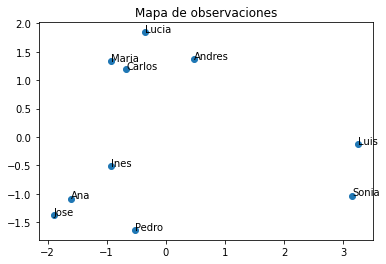

In [14]:
# Mapa de observaciones
x = proyecciones.iloc[:,0]
y = proyecciones.iloc[:,1]

z = df.index
x = x.to_numpy()
y = y.to_numpy()

fig, ax = plt.subplots()
ax.set_title("Mapa de observaciones")
ax.scatter(x, y)

for i, txt in enumerate(z):
    ax.annotate(txt, (x[i], y[i]))

In [17]:
componentes_2 = pd.DataFrame(data = modelo_pca.components_,
    columns = df.columns,
    index = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
)

componentes_2 = componentes_2.iloc[0:2, :]
componentes_2=componentes_2.T
componentes_2

,PC1,PC2
Matematicas,-0.527647,-0.231207
Ciencias,-0.387769,-0.555863
Español,-0.379056,0.550750
Historia,-0.382159,0.556156
Artistica,0.530561,0.157875


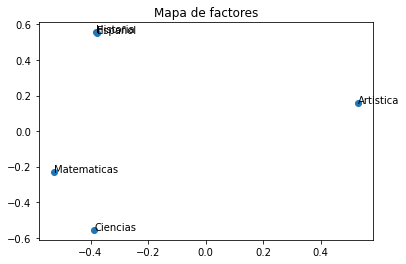

In [18]:
# Mapa de factores
x = componentes_2.iloc[:,0]
y = componentes_2.iloc[:,1]
z = componentes_2.index

x = x.to_numpy()
y = y.to_numpy()

fig, ax = plt.subplots()
ax.set_title("Mapa de factores")
ax.scatter(x, y)

for i, txt in enumerate(z):
    ax.annotate(txt, (x[i], y[i]))